# 02. Newton-Raphson 내부와 Jacobian

Power flow의 미지수는 모든 전압 성분이 아니다. bus type에 따라 이미 고정된 값이 있기 때문이다.

- Slack: `Va`, `Vm`을 기준으로 둔다. reduced Newton system에서는 제외된다.
- PV: `P`, `Vm`이 지정된다. 미지수는 `Va`다.
- PQ: `P`, `Q`가 지정된다. 미지수는 `Va`, `Vm`이다.

따라서 polar Newton의 상태 벡터는 보통 다음처럼 잡는다.

$$
x = [\, V_a(PV,PQ),\; V_m(PQ) \,]
$$

mismatch도 같은 순서로 줄인다.

$$
F(x) = [\, \Delta P(PV,PQ),\; \Delta Q(PQ) \,]
$$

Newton step은 한 문장으로 쓰면 `J dx = -F`다. 아래에서는 `case9`에서 이 한 step이 실제로 어떤 배열을 만드는지 본다.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False
pd.set_option('display.max_colwidth', 120)


In [2]:
case = tu.load_case('case9')
step = tu.newton_step_snapshot(case, case.v0)
summary = pd.DataFrame([
    {'quantity': 'state angle variables Va(PV,PQ)', 'value': len(step.pvpq)},
    {'quantity': 'state magnitude variables Vm(PQ)', 'value': len(case.pq)},
    {'quantity': 'reduced mismatch length', 'value': step.mismatch.size},
    {'quantity': 'Jacobian shape', 'value': f'{step.jacobian.shape[0]} x {step.jacobian.shape[1]}'},
    {'quantity': 'Jacobian nnz', 'value': step.jacobian.nnz},
    {'quantity': '||F(V0)||_inf', 'value': f'{np.linalg.norm(step.mismatch, np.inf):.3e}'},
])
display(summary)
display(tu.newton_step_table(step, limit=12).round(8))


,quantity,value
0,"state angle variables Va(PV,PQ)",8
1,state magnitude variables Vm(PQ),6
2,reduced mismatch length,14
3,Jacobian shape,14 x 14
4,Jacobian nnz,82
5,||F(V0)||_inf,1.630e+00


,unknown,dx
0,Va[2],0.172632
1,Va[3],0.090754
2,Va[4],-0.037108
3,Va[5],-0.062759
4,Va[6],0.042159
5,Va[7],0.019091
6,Va[8],0.073242
7,Va[9],-0.066822
8,Vm(PQ position 1),0.033415
9,Vm(PQ position 2),0.022349


Jacobian은 mismatch가 전압 각도와 전압 크기에 얼마나 민감한지를 담는다. `P`와 `Q`, `Va`와 `Vm`을 나누면 네 block이 생긴다.

$$
J =
\begin{bmatrix}
\partial P / \partial V_a & \partial P / \partial V_m \\
\partial Q / \partial V_a & \partial Q / \partial V_m
\end{bmatrix}
=
\begin{bmatrix}
J_{11} & J_{12} \\
J_{21} & J_{22}
\end{bmatrix}
$$

MATPOWER와 pandapower/PYPOWER 계열은 `S = diag(V) conj(Ybus V)`에서 출발하는 derivative를 쓴다. 핵심 식은 다음과 같다.

$$
I_{bus}=Y_{bus}V,\quad S=diag(V)\overline{I_{bus}}
$$

$$
\frac{\partial V}{\partial V_m}=diag(V/|V|),\quad
\frac{\partial V}{\partial V_a}=j\,diag(V)
$$

$$
\frac{\partial S}{\partial V_m}=diag(V)\overline{Y_{bus}diag(V/|V|)} + \overline{diag(I_{bus})}diag(V/|V|)
$$

$$
\frac{\partial S}{\partial V_a}=j\,diag(V)\overline{diag(I_{bus}) - Y_{bus}diag(V)}
$$

그 뒤 필요한 행/열만 잘라 reduced Jacobian을 만든다. 이 “잘라내기”가 Slack/PV/PQ 정의와 직접 연결된다.


,block,rows,cols,equations,unknowns
0,J11 = dP/dVa,8,8,P at PV+PQ,Va at PV+PQ
1,J12 = dP/dVm,8,6,P at PV+PQ,Vm at PQ
2,J21 = dQ/dVa,6,8,Q at PQ,Va at PV+PQ
3,J22 = dQ/dVm,6,6,Q at PQ,Vm at PQ


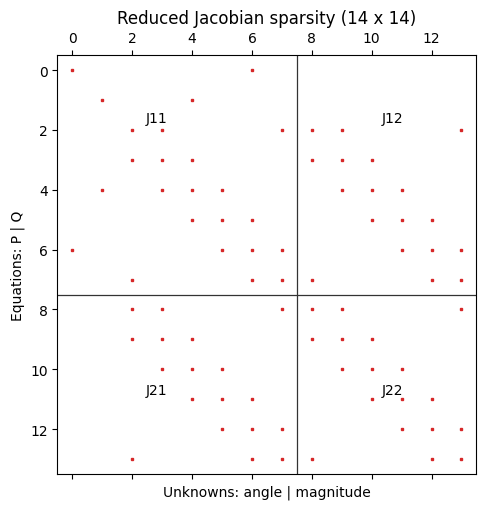

In [3]:
display(tu.jacobian_block_shapes(case))
fig, ax = plt.subplots(figsize=(6, 5.2))
tu.plot_jacobian_block_pattern(case, case.v0, ax)
plt.tight_layout()


한 번의 Newton update가 끝나면 mismatch가 줄어야 한다. 아래 표는 `V0`와 한 번 갱신한 `V1`에서 mismatch norm을 비교한다. 이것이 반복의 목적이다.


,voltage,mismatch_inf_norm
0,V0,1.630000
1,after one Newton step,0.187516


converged=True, iterations=4, final_mismatch=1.842e-14


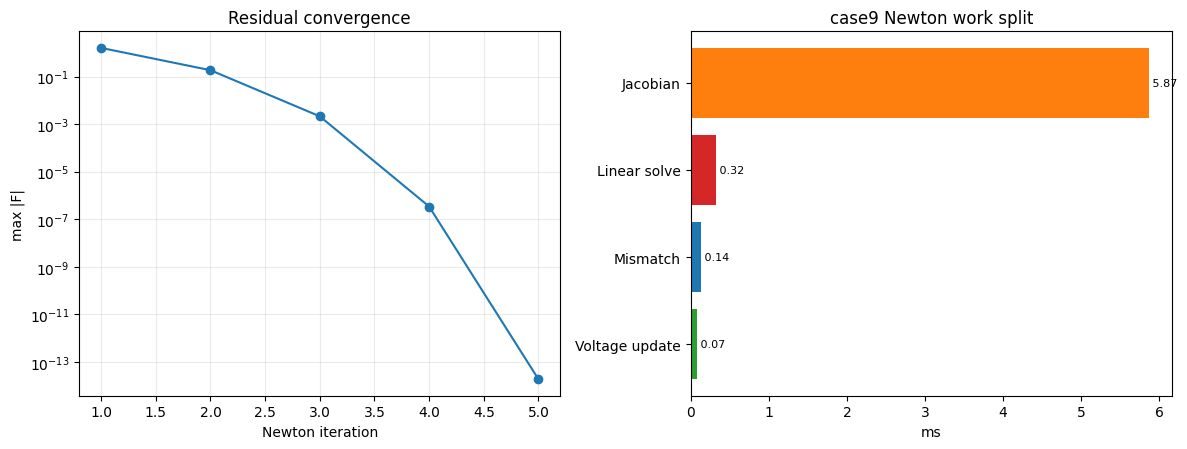

In [4]:
s0 = tu.power_flow_snapshot(case, step.voltage)
s1 = tu.power_flow_snapshot(case, step.next_voltage)
display(pd.DataFrame([
    {'voltage': 'V0', 'mismatch_inf_norm': np.linalg.norm(s0.mismatch_reduced, np.inf)},
    {'voltage': 'after one Newton step', 'mismatch_inf_norm': np.linalg.norm(s1.mismatch_reduced, np.inf)},
]).round(10))
trace = tu.newton_trace(case, tolerance=1e-8, max_iter=50)
print(f"converged={trace.converged}, iterations={trace.iterations}, final_mismatch={trace.final_mismatch:.3e}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
tu.plot_newton_convergence(trace, axes[0])
tu.plot_stage_timing(trace.stage_totals_ms, axes[1], 'case9 Newton work split')
plt.tight_layout()


여기까지가 이후 모든 구현의 공통 뼈대다. MATPOWER, pandapower, cuPF CPU, cuPF GPU는 모두 이 반복 구조 안에서 `Jacobian을 어떻게 만들고`, `J dx = -F를 어떤 solver로 푸는가`를 다르게 선택한다.

참고 자료:

- MATPOWER AC Power Flow manual: https://matpower.app/manual/matpower/ACPowerFlow.html
- MATPOWER `dSbus_dV` reference: https://matpower.org/docs/ref/matpower7.0/lib/dSbus_dV.html
